# ITSM / Customer Support Ticket Routing

**Multi-task NLP: предсказание queue (52 класса), priority (5 классов), type (5 классов)**

### Подходы
1. TF-IDF + SGDClassifier (baseline)
2. Word2Vec + SGDClassifier
3. Fine-tuning BGE - M3 (multitask) via HuggingFace Trainer + SDPA

### Итоговая метрика
```
Score = 0.70 × MacroF1(queue) + 0.15 × Acc(priority) + 0.15 × Acc(type)
```

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 0. Загрузка данных и фиксированный split

In [2]:
DATASET = "Tobi-Bueck/customer-support-tickets"
ds = load_dataset(DATASET)
df_full = ds["train"].to_pandas()

DATA_DIR = Path("data")
train_idx = np.loadtxt(DATA_DIR / "train_idx.txt", dtype=np.int64)
val_idx = np.loadtxt(DATA_DIR / "val_idx.txt", dtype=np.int64)
test_idx = np.loadtxt(DATA_DIR / "test_idx.txt", dtype=np.int64)

df_train = df_full.iloc[train_idx].copy().reset_index(drop=True)
df_val = df_full.iloc[val_idx].copy().reset_index(drop=True)
df_test = df_full.iloc[test_idx].copy().reset_index(drop=True)

for d in [df_train, df_val, df_test]:
    d["type"] = d["type"].fillna("Unknown")


def make_text(df):
    return (df["subject"].fillna("") + " " + df["body"].fillna("")).astype(str)


df_train["text"] = make_text(df_train)
df_val["text"] = make_text(df_val)
df_test["text"] = make_text(df_test)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
print(f"Columns: {list(df_full.columns)}")
df_train.head(3)

Train: 49412, Val: 6176, Test: 6177
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None,"Account Disruption Dear Customer Support Team,..."
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None,Query About Smart Home System Integration Feat...


---
## 1. Exploratory Data Analysis (EDA)

In [3]:
print("=== Missing values (доля пропусков) ===")
for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    miss = df[["subject", "body", "queue", "priority", "type"]].isna().mean()
    print(f"\n{name}:")
    if miss.any():
        print(miss[miss > 0].to_string())
    else:
        print("  No missing values in key columns")

=== Missing values (доля пропусков) ===

train:
subject    0.086376
body       0.000040

val:
subject    0.081768

test:
subject    0.085155


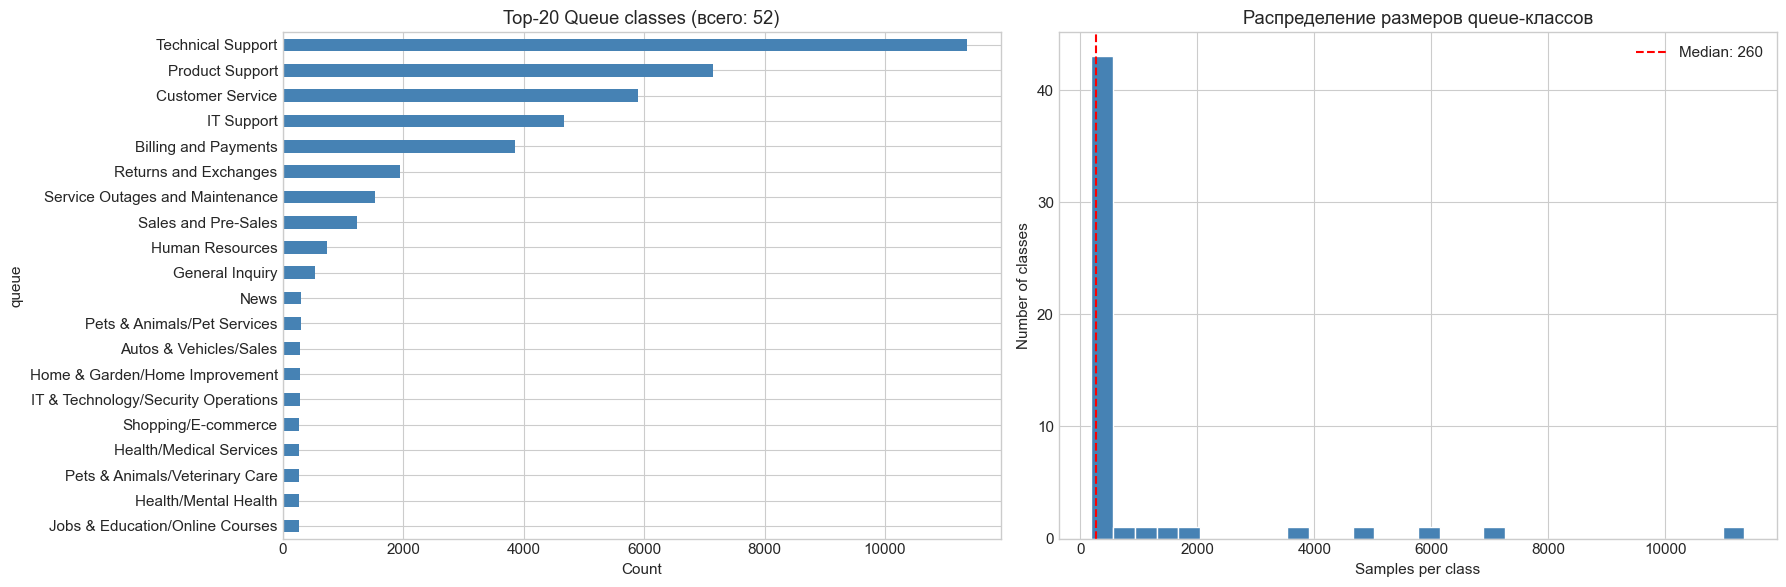


Queue: 52 classes
Min class: 187, Max: 11354, Median: 260

Наименьшие 5 классов:
queue
Home & Garden/Landscaping               217
Arts & Entertainment/Movies             207
IT & Technology/Software Development    206
Sports                                  190
Real Estate                             187
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

queue_counts = df_train["queue"].value_counts()
queue_counts.head(20).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title(f"Top-20 Queue classes (всего: {df_train['queue'].nunique()})")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

axes[1].hist(queue_counts.values, bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Распределение размеров queue-классов")
axes[1].set_xlabel("Samples per class")
axes[1].set_ylabel("Number of classes")
axes[1].axvline(
    queue_counts.median(),
    color="red",
    ls="--",
    label=f"Median: {queue_counts.median():.0f}",
)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nQueue: {df_train['queue'].nunique()} classes")
print(
    f"Min class: {queue_counts.min()}, Max: {queue_counts.max()}, "
    f"Median: {queue_counts.median():.0f}"
)
print(f"\nНаименьшие 5 классов:\n{queue_counts.tail(5)}")

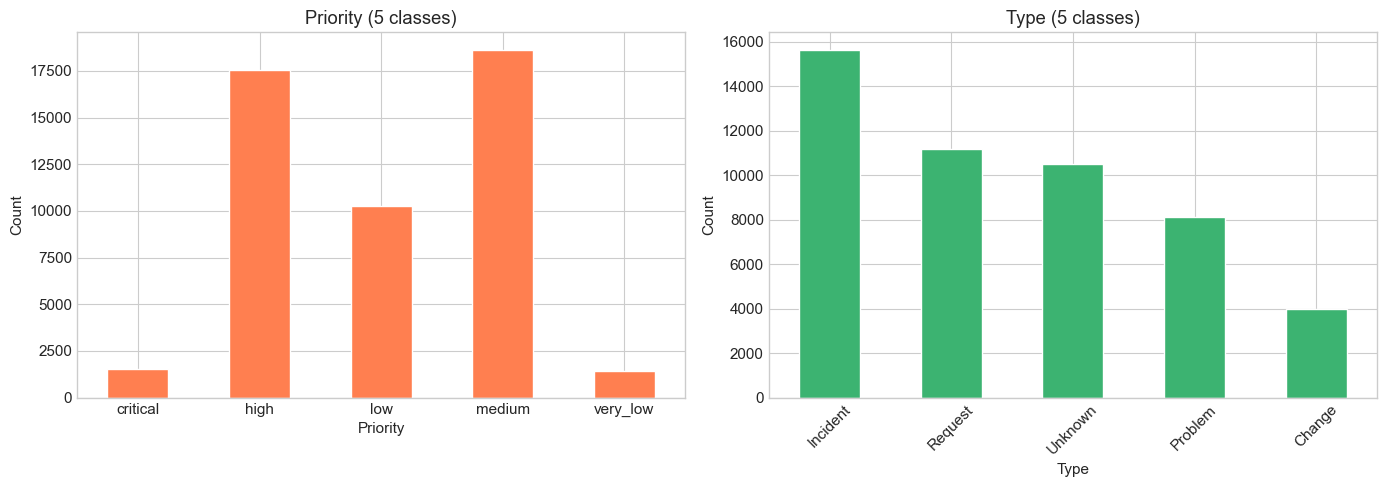

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train["priority"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="coral", edgecolor="white"
)
axes[0].set_title(f"Priority ({df_train['priority'].nunique()} classes)")
axes[0].set_xlabel("Priority")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df_train["type"].value_counts().plot(
    kind="bar", ax=axes[1], color="mediumseagreen", edgecolor="white"
)
axes[1].set_title(f"Type ({df_train['type'].nunique()} classes)")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

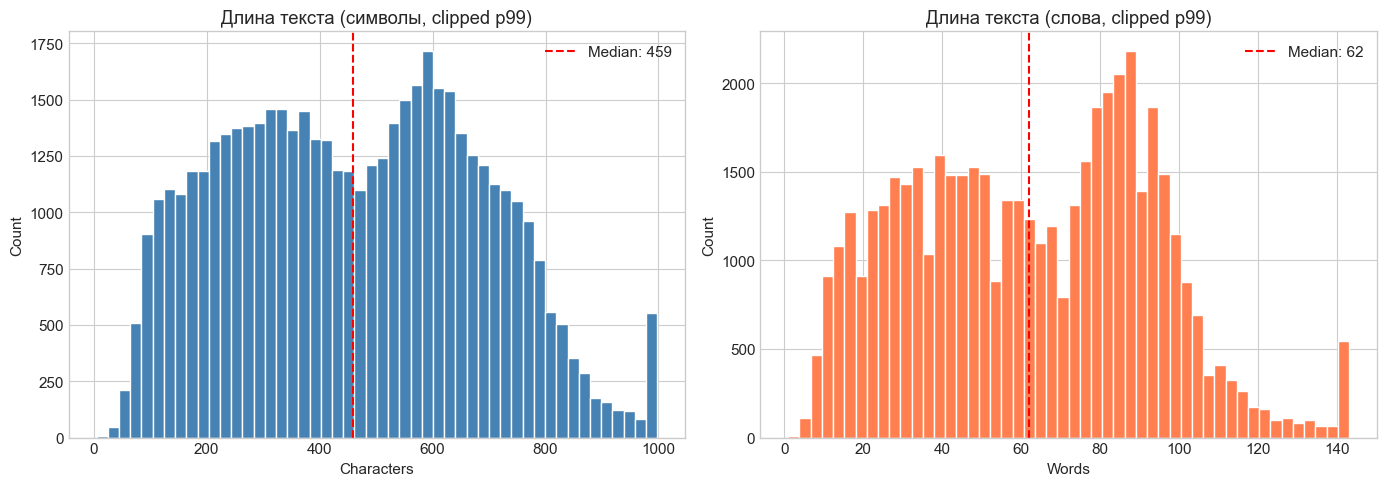

Chars: mean=464, median=459, p90=754, p99=998
Words: mean=62, median=62, p90=99, p99=143


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

char_lens = df_train["text"].str.len()
axes[0].hist(
    char_lens.clip(upper=char_lens.quantile(0.99)),
    bins=50,
    color="steelblue",
    edgecolor="white",
)
axes[0].set_title("Длина текста (символы, clipped p99)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
axes[0].axvline(
    char_lens.median(), color="red", ls="--", label=f"Median: {char_lens.median():.0f}"
)
axes[0].legend()

word_lens = df_train["text"].str.split().str.len()
axes[1].hist(
    word_lens.clip(upper=word_lens.quantile(0.99)),
    bins=50,
    color="coral",
    edgecolor="white",
)
axes[1].set_title("Длина текста (слова, clipped p99)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")
axes[1].axvline(
    word_lens.median(), color="red", ls="--", label=f"Median: {word_lens.median():.0f}"
)
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    f"Chars: mean={char_lens.mean():.0f}, median={char_lens.median():.0f}, "
    f"p90={char_lens.quantile(0.9):.0f}, p99={char_lens.quantile(0.99):.0f}"
)
print(
    f"Words: mean={word_lens.mean():.0f}, median={word_lens.median():.0f}, "
    f"p90={word_lens.quantile(0.9):.0f}, p99={word_lens.quantile(0.99):.0f}"
)

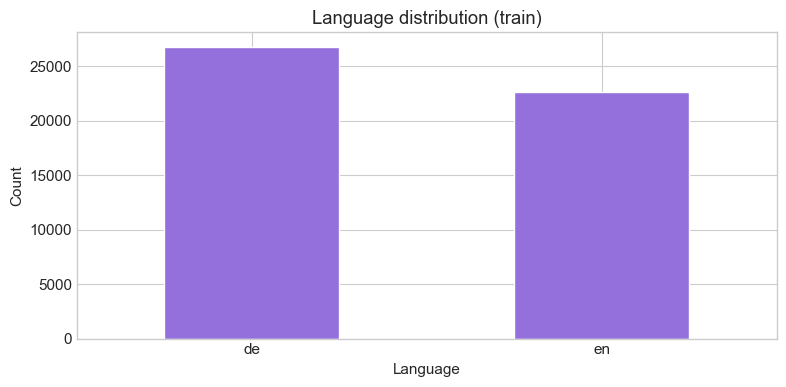

train: {'de': 26799, 'en': 22613}
val: {'de': 3375, 'en': 2801}
test: {'de': 3330, 'en': 2847}


In [7]:
if "language" in df_train.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    lang_counts = df_train["language"].fillna("NA").value_counts()
    lang_counts.plot(kind="bar", ax=ax, color="mediumpurple", edgecolor="white")
    ax.set_title("Language distribution (train)")
    ax.set_xlabel("Language")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

    for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
        print(f"{name}: {df['language'].fillna('NA').value_counts().to_dict()}")

### Дополнительные графики для EDA

Эти графики помогают понять не только маргинальные распределения, но и структуру датасета: насколько выражен long-tail у `queue`, как связаны `priority` и `type`, и отличаются ли длины тикетов между типами обращений.

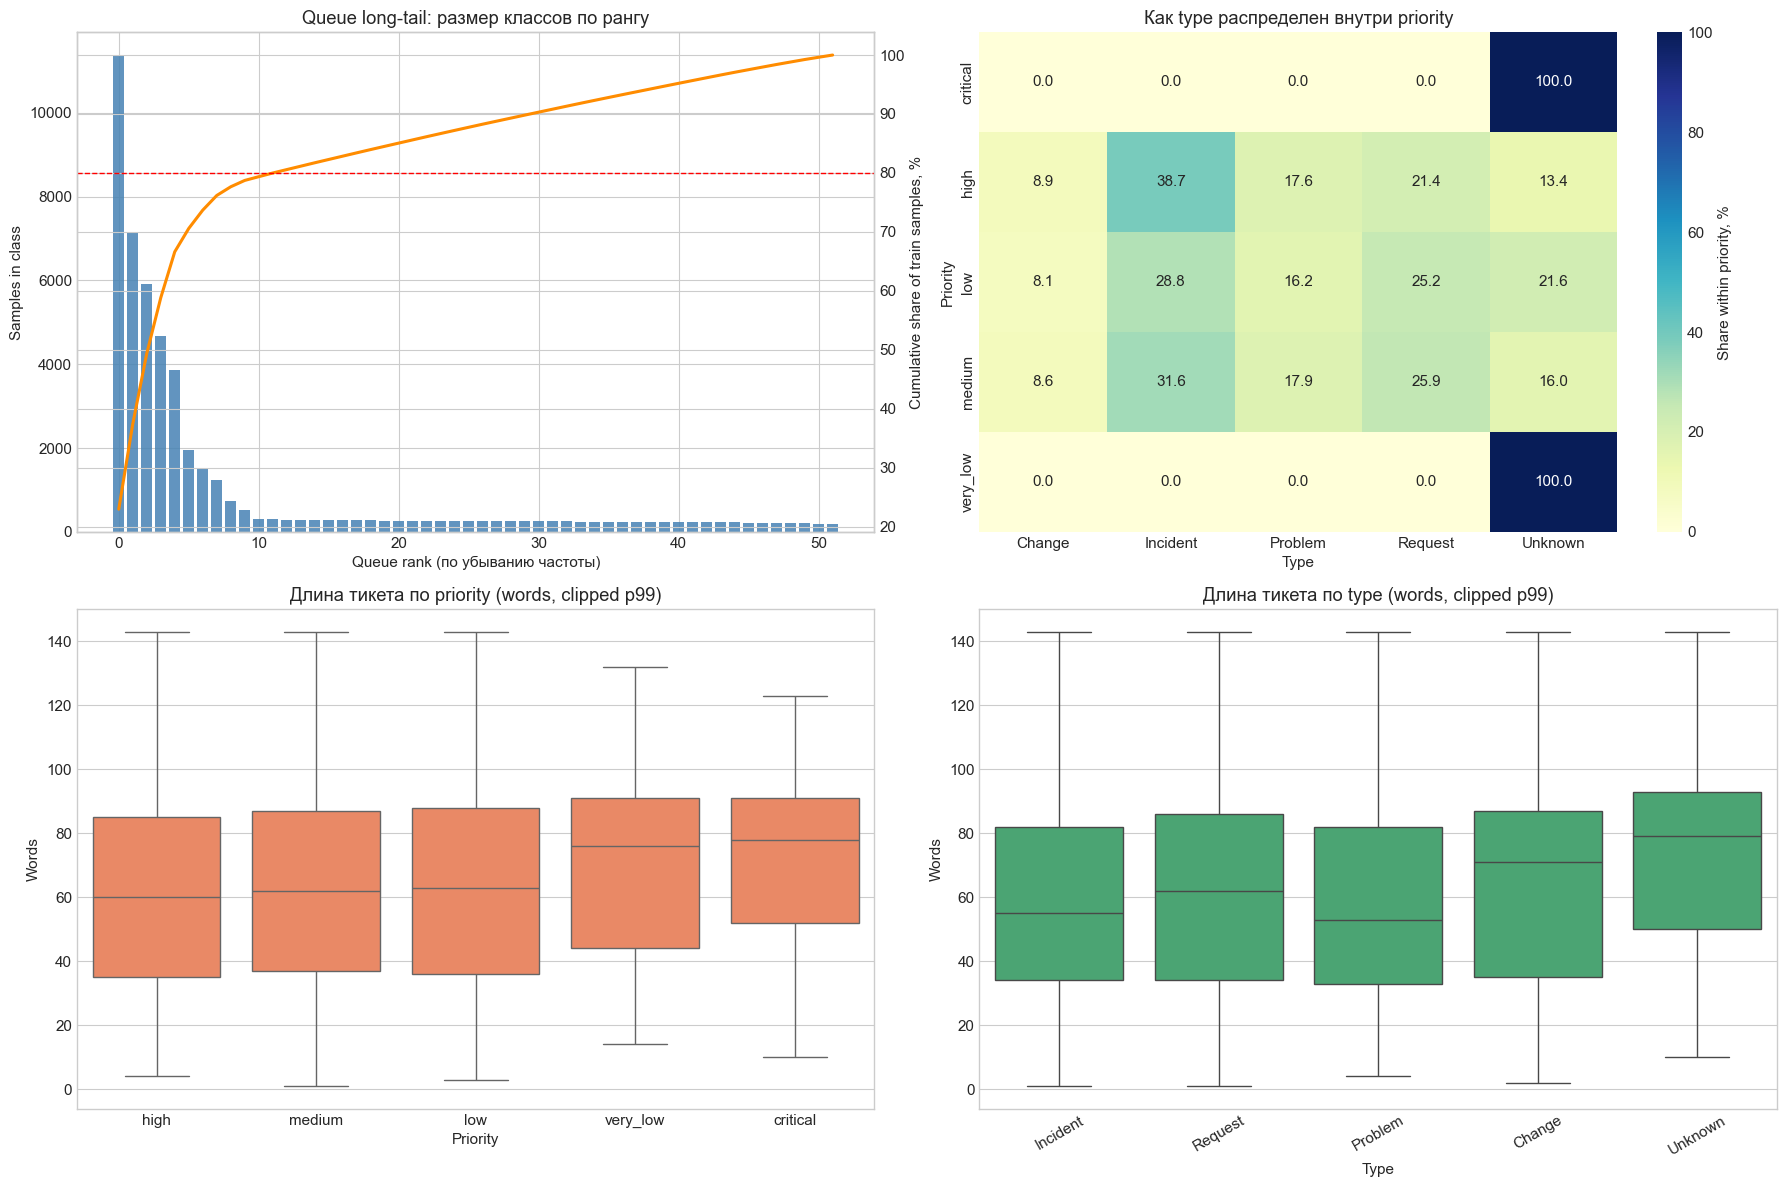

Первые 13 queue-классов покрывают примерно 80% train-выборки.

Median words by priority:
priority
critical    78.0
high        60.0
low         63.0
medium      62.0
very_low    76.0

Median words by type:
type
Unknown     79.0
Change      71.0
Request     62.0
Incident    55.0
Problem     53.0


In [8]:
eda_df = df_train.copy()
eda_df["word_len"] = eda_df["text"].str.split().str.len()
eda_df["word_len_clipped"] = eda_df["word_len"].clip(upper=eda_df["word_len"].quantile(0.99))

queue_counts_sorted = df_train["queue"].value_counts().sort_values(ascending=False)
queue_share = queue_counts_sorted.cumsum() / queue_counts_sorted.sum() * 100
priority_type_share = pd.crosstab(
    df_train["priority"],
    df_train["type"],
    normalize="index",
) * 100

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].bar(
    np.arange(len(queue_counts_sorted)),
    queue_counts_sorted.values,
    color="steelblue",
    alpha=0.85,
)
axes[0, 0].set_title("Queue long-tail: размер классов по рангу")
axes[0, 0].set_xlabel("Queue rank (по убыванию частоты)")
axes[0, 0].set_ylabel("Samples in class")

ax0_twin = axes[0, 0].twinx()
ax0_twin.plot(
    np.arange(len(queue_share)),
    queue_share.values,
    color="darkorange",
    linewidth=2.2,
)
ax0_twin.axhline(80, color="red", ls="--", linewidth=1)
ax0_twin.set_ylabel("Cumulative share of train samples, %")

sns.heatmap(
    priority_type_share.round(1),
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    ax=axes[0, 1],
    cbar_kws={"label": "Share within priority, %"},
)
axes[0, 1].set_title("Как type распределен внутри priority")
axes[0, 1].set_xlabel("Type")
axes[0, 1].set_ylabel("Priority")

sns.boxplot(
    data=eda_df,
    x="priority",
    y="word_len_clipped",
    ax=axes[1, 0],
    color="coral",
    showfliers=False,
)
axes[1, 0].set_title("Длина тикета по priority (words, clipped p99)")
axes[1, 0].set_xlabel("Priority")
axes[1, 0].set_ylabel("Words")

sns.boxplot(
    data=eda_df,
    x="type",
    y="word_len_clipped",
    ax=axes[1, 1],
    color="mediumseagreen",
    showfliers=False,
)
axes[1, 1].set_title("Длина тикета по type (words, clipped p99)")
axes[1, 1].set_xlabel("Type")
axes[1, 1].set_ylabel("Words")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

n80 = int((queue_share < 80).sum() + 1)
print(f"Первые {n80} queue-классов покрывают примерно 80% train-выборки.")
print("\nMedian words by priority:")
print(eda_df.groupby("priority")["word_len"].median().sort_index().to_string())
print("\nMedian words by type:")
print(eda_df.groupby("type")["word_len"].median().sort_values(ascending=False).to_string())

---
## Helper functions: scoring & confidence analysis

In [9]:
def compute_score(y_queue, pred_queue, y_priority, pred_priority, y_type, pred_type):
    """Score = 0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type)"""
    mf1_queue = f1_score(y_queue, pred_queue, average="macro")
    acc_queue = accuracy_score(y_queue, pred_queue)
    acc_priority = accuracy_score(y_priority, pred_priority)
    acc_type = accuracy_score(y_type, pred_type)
    score = 0.70 * mf1_queue + 0.15 * acc_priority + 0.15 * acc_type
    return {
        "MacroF1(queue)": mf1_queue,
        "Acc(queue)": acc_queue,
        "Acc(priority)": acc_priority,
        "Acc(type)": acc_type,
        "Score": score,
    }


def print_results(results, model_name="Model"):
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    for k, v in results.items():
        print(f"  {k:20s}: {v:.4f}")
    print(f"{'='*55}")


def confidence_coverage_analysis(
    y_true, y_pred, confidences, metric_fn, metric_name="Metric"
):
    """
    Анализ selective prediction:
    берём top-X% наиболее уверенных предсказаний,
    остальные уходят на ручную разметку.
    """
    sorted_idx = np.argsort(-confidences)
    coverages = np.arange(0.05, 1.01, 0.05)
    rows = []
    for cov in coverages:
        n = max(1, int(len(y_true) * cov))
        idx = sorted_idx[:n]
        score = metric_fn(np.array(y_true)[idx], np.array(y_pred)[idx])
        rows.append(
            {
                "coverage": round(cov, 2),
                "n_samples": n,
                metric_name: round(score, 4),
                "min_confidence": round(float(confidences[sorted_idx[n - 1]]), 4),
            }
        )
    return pd.DataFrame(rows)


def plot_confidence_curve(conf_df, metric_name, title, color="steelblue"):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(
        conf_df["coverage"],
        conf_df[metric_name],
        "o-",
        color=color,
        linewidth=2,
        markersize=5,
    )
    ax1.set_xlabel("Coverage (доля автоклассифицированных)")
    ax1.set_ylabel(metric_name, color=color)
    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        conf_df["coverage"],
        conf_df["min_confidence"],
        "s--",
        color="gray",
        alpha=0.5,
        linewidth=1,
        markersize=4,
    )
    ax2.set_ylabel("Min confidence at threshold", color="gray")

    plt.tight_layout()
    plt.show()


all_model_results = {}
all_conf_curves = {}

---
## 2. Baseline: TF-IDF + SGDClassifier

In [10]:
tfidf = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(df_train["text"])
X_val_tfidf = tfidf.transform(df_val["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (49412, 200000)


In [11]:
tfidf_preds = {}
tfidf_probas = {}

for target in ["queue", "priority", "type"]:
    print(f"Training SGDClassifier for '{target}'...")
    base = SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=100,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf = CalibratedClassifierCV(base, cv=3, n_jobs=-1)
    clf.fit(X_train_tfidf, df_train[target].astype(str))

    tfidf_preds[target] = clf.predict(X_test_tfidf)
    tfidf_probas[target] = clf.predict_proba(X_test_tfidf)

    acc = accuracy_score(df_test[target].astype(str), tfidf_preds[target])
    if target == "queue":
        mf1 = f1_score(
            df_test[target].astype(str), tfidf_preds[target], average="macro"
        )
        print(f"  {target}: Acc={acc:.4f}, MacroF1={mf1:.4f}")
    else:
        print(f"  {target}: Acc={acc:.4f}")

tfidf_results = compute_score(
    df_test["queue"].astype(str),
    tfidf_preds["queue"],
    df_test["priority"].astype(str),
    tfidf_preds["priority"],
    df_test["type"].astype(str),
    tfidf_preds["type"],
)
print_results(tfidf_results, "TF-IDF + SGDClassifier")
all_model_results["TF-IDF + SGD"] = tfidf_results

Training SGDClassifier for 'queue'...
  queue: Acc=0.5224, MacroF1=0.6940
Training SGDClassifier for 'priority'...
  priority: Acc=0.5705
Training SGDClassifier for 'type'...
  type: Acc=0.8451

  TF-IDF + SGDClassifier
  MacroF1(queue)      : 0.6940
  Acc(queue)          : 0.5224
  Acc(priority)       : 0.5705
  Acc(type)           : 0.8451
  Score               : 0.6981


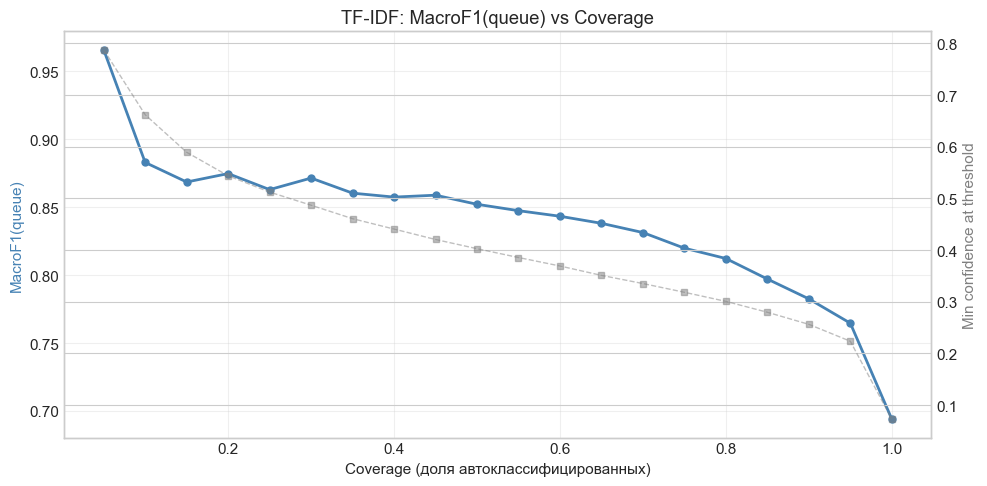

 coverage  n_samples  MacroF1(queue)  min_confidence
     0.05        308          0.9658          0.7878
     0.10        617          0.8829          0.6621
     0.15        926          0.8685          0.5894
     0.20       1235          0.8747          0.5439
     0.25       1544          0.8629          0.5123
     0.30       1853          0.8714          0.4869
     0.35       2161          0.8603          0.4608
     0.40       2470          0.8574          0.4407
     0.45       2779          0.8588          0.4205
     0.50       3088          0.8521          0.4027
     0.55       3397          0.8474          0.3856
     0.60       3706          0.8433          0.3692
     0.65       4015          0.8381          0.3510
     0.70       4323          0.8313          0.3352
     0.75       4632          0.8198          0.3183
     0.80       4941          0.8122          0.3007
     0.85       5250          0.7971          0.2796
     0.90       5559          0.7825          

In [12]:
tfidf_conf = confidence_coverage_analysis(
    df_test["queue"].astype(str).values,
    tfidf_preds["queue"],
    np.max(tfidf_probas["queue"], axis=1),
    lambda y, p: f1_score(y, p, average="macro"),
    "MacroF1(queue)",
)
all_conf_curves["TF-IDF + SGD"] = tfidf_conf

plot_confidence_curve(
    tfidf_conf,
    "MacroF1(queue)",
    "TF-IDF: MacroF1(queue) vs Coverage",
    color="steelblue",
)
print(tfidf_conf.to_string(index=False))

---
## 3. Word2Vec + SGDClassifier

In [13]:
from gensim.models import Word2Vec
from tqdm import tqdm


def simple_tokenize(text):
    import re

    return re.findall(r"\w+", text.lower())


sentences_train = [simple_tokenize(t) for t in df_train["text"]]

w2v = Word2Vec(
    sentences_train,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    epochs=15,
    seed=RANDOM_STATE,
)
print(f"Word2Vec vocabulary: {len(w2v.wv)} words, dim={w2v.wv.vector_size}")

Word2Vec vocabulary: 23937 words, dim=300


In [14]:
def text_to_vec(text, model, dim=300):
    tokens = simple_tokenize(text)
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)


print("Vectorizing train...")
X_train_w2v = np.array([text_to_vec(t, w2v) for t in tqdm(df_train["text"])])
print("Vectorizing val...")
X_val_w2v = np.array([text_to_vec(t, w2v) for t in tqdm(df_val["text"])])
print("Vectorizing test...")
X_test_w2v = np.array([text_to_vec(t, w2v) for t in tqdm(df_test["text"])])

print(f"W2V features shape: {X_train_w2v.shape}")

Vectorizing train...


100%|██████████| 49412/49412 [00:03<00:00, 14793.72it/s]


Vectorizing val...


100%|██████████| 6176/6176 [00:00<00:00, 14635.06it/s]


Vectorizing test...


100%|██████████| 6177/6177 [00:00<00:00, 14690.81it/s]

W2V features shape: (49412, 300)


In [15]:
w2v_preds = {}
w2v_probas = {}

for target in ["queue", "priority", "type"]:
    print(f"Training SGDClassifier (W2V) for '{target}'...")
    base = SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=100,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf = CalibratedClassifierCV(base, cv=3, n_jobs=-1)
    clf.fit(X_train_w2v, df_train[target].astype(str))

    w2v_preds[target] = clf.predict(X_test_w2v)
    w2v_probas[target] = clf.predict_proba(X_test_w2v)

    acc = accuracy_score(df_test[target].astype(str), w2v_preds[target])
    if target == "queue":
        mf1 = f1_score(df_test[target].astype(str), w2v_preds[target], average="macro")
        print(f"  {target}: Acc={acc:.4f}, MacroF1={mf1:.4f}")
    else:
        print(f"  {target}: Acc={acc:.4f}")

w2v_results = compute_score(
    df_test["queue"].astype(str),
    w2v_preds["queue"],
    df_test["priority"].astype(str),
    w2v_preds["priority"],
    df_test["type"].astype(str),
    w2v_preds["type"],
)
print_results(w2v_results, "Word2Vec + SGDClassifier")
all_model_results["Word2Vec + SGD"] = w2v_results

Training SGDClassifier (W2V) for 'queue'...
  queue: Acc=0.3304, MacroF1=0.1778
Training SGDClassifier (W2V) for 'priority'...
  priority: Acc=0.4965
Training SGDClassifier (W2V) for 'type'...
  type: Acc=0.8190

  Word2Vec + SGDClassifier
  MacroF1(queue)      : 0.1778
  Acc(queue)          : 0.3304
  Acc(priority)       : 0.4965
  Acc(type)           : 0.8190
  Score               : 0.3218


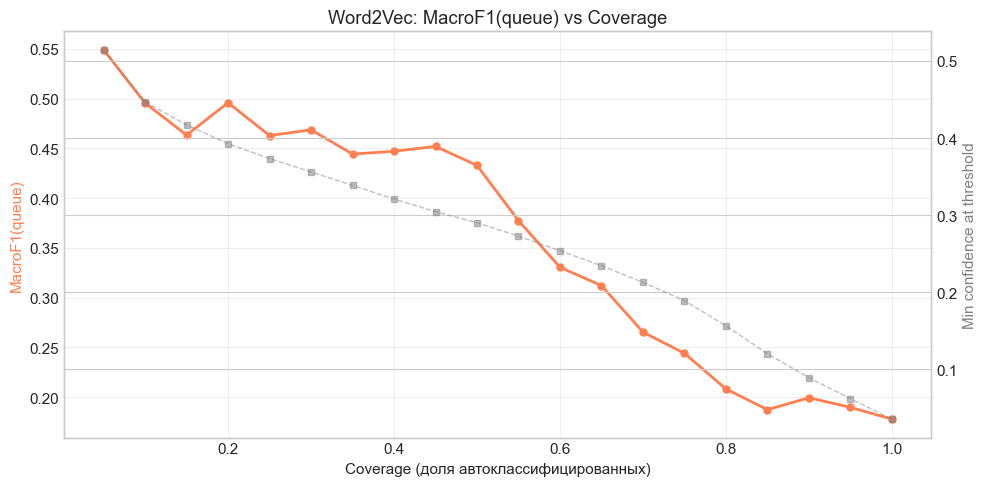

 coverage  n_samples  MacroF1(queue)  min_confidence
     0.05        308          0.5490          0.5144
     0.10        617          0.4955          0.4467
     0.15        926          0.4633          0.4171
     0.20       1235          0.4958          0.3926
     0.25       1544          0.4628          0.3734
     0.30       1853          0.4686          0.3560
     0.35       2161          0.4442          0.3385
     0.40       2470          0.4470          0.3208
     0.45       2779          0.4519          0.3045
     0.50       3088          0.4328          0.2901
     0.55       3397          0.3773          0.2727
     0.60       3706          0.3304          0.2538
     0.65       4015          0.3120          0.2344
     0.70       4323          0.2653          0.2127
     0.75       4632          0.2439          0.1891
     0.80       4941          0.2081          0.1564
     0.85       5250          0.1873          0.1202
     0.90       5559          0.1993          

In [16]:
w2v_conf = confidence_coverage_analysis(
    df_test["queue"].astype(str).values,
    w2v_preds["queue"],
    np.max(w2v_probas["queue"], axis=1),
    lambda y, p: f1_score(y, p, average="macro"),
    "MacroF1(queue)",
)
all_conf_curves["Word2Vec + SGD"] = w2v_conf

plot_confidence_curve(
    w2v_conf, "MacroF1(queue)", "Word2Vec: MacroF1(queue) vs Coverage", color="coral"
)
print(w2v_conf.to_string(index=False))

---
## 4. Fine-tuning BAAI/bge-m3 (Multitask) via HuggingFace Trainer

Multitask-модель с тремя головами: **queue**, **priority**, **type**.  
Backbone: `BAAI/bge-m3` — мультиязычный encoder (на базе XLM-RoBERTa, 568M параметров).  
Используем **Flash Attention 2** + **Trainer** API + **accelerate** + **fp16** mixed precision.

In [17]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_NAME = "BAAI/bge-m3"
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 3
LR = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Device: cuda
GPU: NVIDIA GeForce RTX 5080
Memory: 17.1 GB


In [18]:
label_encoders = {}
for target in ["queue", "priority", "type"]:
    le = LabelEncoder()
    le.fit(df_train[target].astype(str))
    label_encoders[target] = le
    for d in [df_train, df_val, df_test]:
        d[f"{target}_enc"] = le.transform(d[target].astype(str))

num_classes = {t: len(le.classes_) for t, le in label_encoders.items()}
print(f"Number of classes: {num_classes}")


class TicketDataset(Dataset):
    def __init__(self, texts, labels_dict, tokenizer, max_len):
        self.texts = texts
        self.labels = labels_dict
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels_queue"] = torch.tensor(self.labels["queue"][idx], dtype=torch.long)
        item["labels_priority"] = torch.tensor(
            self.labels["priority"][idx], dtype=torch.long
        )
        item["labels_type"] = torch.tensor(self.labels["type"][idx], dtype=torch.long)
        return item


def make_labels_dict(df):
    return {t: df[f"{t}_enc"].values for t in ["queue", "priority", "type"]}


train_ds = TicketDataset(
    df_train["text"].tolist(), make_labels_dict(df_train), tokenizer, MAX_LEN
)
val_ds = TicketDataset(
    df_val["text"].tolist(), make_labels_dict(df_val), tokenizer, MAX_LEN
)
test_ds = TicketDataset(
    df_test["text"].tolist(), make_labels_dict(df_test), tokenizer, MAX_LEN
)

print(f"Datasets: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

Number of classes: {'queue': 52, 'priority': 5, 'type': 5}
Datasets: train=49412, val=6176, test=6177


In [19]:
class MultitaskTicketModel(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(
            model_name,
            attn_implementation="sdpa",
        )
        h = self.backbone.config.hidden_size
        self.drop = nn.Dropout(dropout)
        self.head_queue = nn.Linear(h, n_queue)
        self.head_priority = nn.Linear(h, n_priority)
        self.head_type = nn.Linear(h, n_type)
        self.config = self.backbone.config

    def forward(
        self,
        input_ids,
        attention_mask,
        labels_queue=None,
        labels_priority=None,
        labels_type=None,
        **kwargs,
    ):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        # CLS-token pooling (bge-m3 — encoder на базе XLM-RoBERTa)
        cls_out = self.drop(out.last_hidden_state[:, 0, :])

        lq = self.head_queue(cls_out)
        lp = self.head_priority(cls_out)
        lt = self.head_type(cls_out)

        loss = None
        if labels_queue is not None:
            ce = nn.CrossEntropyLoss()
            loss = (
                0.70 * ce(lq.float(), labels_queue)
                + 0.15 * ce(lp.float(), labels_priority)
                + 0.15 * ce(lt.float(), labels_type)
            )

        return {
            "loss": loss,
            "logits_queue": lq,
            "logits_priority": lp,
            "logits_type": lt,
        }


class MultitaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss


model = MultitaskTicketModel(
    MODEL_NAME,
    num_classes["queue"],
    num_classes["priority"],
    num_classes["type"],
)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 567,818,302


In [20]:
training_args = TrainingArguments(
    output_dir="./bge_m3_multitask_ckpt",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=4,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    dataloader_num_workers=0,
    report_to="none",
    seed=RANDOM_STATE,
    remove_unused_columns=False,
)

trainer = MultitaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()
print("Training complete!")

Epoch,Training Loss,Validation Loss
1,1.075100,1.055517
2,0.873900,0.892511
3,0.690100,0.845987


Training complete!


In [21]:
model.eval()
model.to(device)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0
)

test_preds_t = {t: [] for t in ["queue", "priority", "type"]}
test_probas_t = {t: [] for t in ["queue", "priority", "type"]}

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test evaluation"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids, attention_mask)
        for t in ["queue", "priority", "type"]:
            logits = outputs[f"logits_{t}"].float()
            probs = torch.softmax(logits, dim=1)
            test_preds_t[t].extend(logits.argmax(dim=1).cpu().numpy())
            test_probas_t[t].extend(probs.cpu().numpy())

transformer_preds = {}
transformer_probas = {}
for t in ["queue", "priority", "type"]:
    transformer_preds[t] = label_encoders[t].inverse_transform(test_preds_t[t])
    transformer_probas[t] = np.array(test_probas_t[t])

transformer_results = compute_score(
    df_test["queue"].astype(str),
    transformer_preds["queue"],
    df_test["priority"].astype(str),
    transformer_preds["priority"],
    df_test["type"].astype(str),
    transformer_preds["type"],
)
print_results(transformer_results, "BGE-M3 Multitask")
all_model_results["BGE-M3 Multitask"] = transformer_results

Test evaluation: 100%|██████████| 387/387 [00:16<00:00, 24.19it/s]


  BGE-M3 Multitask
  MacroF1(queue)      : 0.8897
  Acc(queue)          : 0.6689
  Acc(priority)       : 0.6037
  Acc(type)           : 0.8640
  Score               : 0.8430


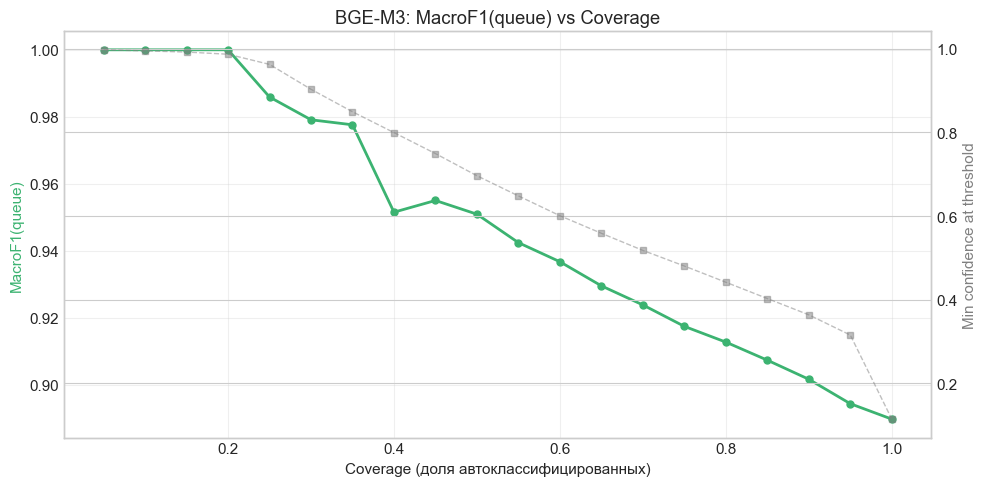

 coverage  n_samples  MacroF1(queue)  min_confidence
     0.05        308          1.0000          0.9979
     0.10        617          1.0000          0.9953
     0.15        926          1.0000          0.9925
     0.20       1235          1.0000          0.9873
     0.25       1544          0.9859          0.9630
     0.30       1853          0.9791          0.9034
     0.35       2161          0.9776          0.8496
     0.40       2470          0.9515          0.7997
     0.45       2779          0.9550          0.7495
     0.50       3088          0.9509          0.6965
     0.55       3397          0.9424          0.6482
     0.60       3706          0.9367          0.6008
     0.65       4015          0.9295          0.5587
     0.70       4323          0.9238          0.5178
     0.75       4632          0.9174          0.4804
     0.80       4941          0.9127          0.4416
     0.85       5250          0.9073          0.4026
     0.90       5559          0.9016          

In [22]:
transformer_conf = confidence_coverage_analysis(
    df_test["queue"].astype(str).values,
    transformer_preds["queue"],
    np.max(transformer_probas["queue"], axis=1),
    lambda y, p: f1_score(y, p, average="macro"),
    "MacroF1(queue)",
)
all_conf_curves["BGE-M3 Multitask"] = transformer_conf

plot_confidence_curve(
    transformer_conf,
    "MacroF1(queue)",
    "BGE-M3: MacroF1(queue) vs Coverage",
    color="mediumseagreen",
)
print(transformer_conf.to_string(index=False))

---
## 5. Итоговое сравнение моделей

In [23]:
comparison_df = pd.DataFrame(all_model_results).T
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values("Score", ascending=False)

print("=" * 70)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (test set)")
print("=" * 70)
print(comparison_df.to_string())
print("=" * 70)
print(
    f"\nЛучшая модель по Score: {comparison_df['Score'].idxmax()} "
    f"({comparison_df['Score'].max():.4f})"
)
print(
    f"Тай-брейк MacroF1(queue): {comparison_df['MacroF1(queue)'].idxmax()} "
    f"({comparison_df['MacroF1(queue)'].max():.4f})"
)

ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (test set)
                  MacroF1(queue)  Acc(queue)  Acc(priority)  Acc(type)   Score
BGE-M3 Multitask          0.8897      0.6689         0.6037     0.8640  0.8430
TF-IDF + SGD              0.6940      0.5224         0.5705     0.8451  0.6981
Word2Vec + SGD            0.1778      0.3304         0.4965     0.8190  0.3218

Лучшая модель по Score: BGE-M3 Multitask (0.8430)
Тай-брейк MacroF1(queue): BGE-M3 Multitask (0.8897)


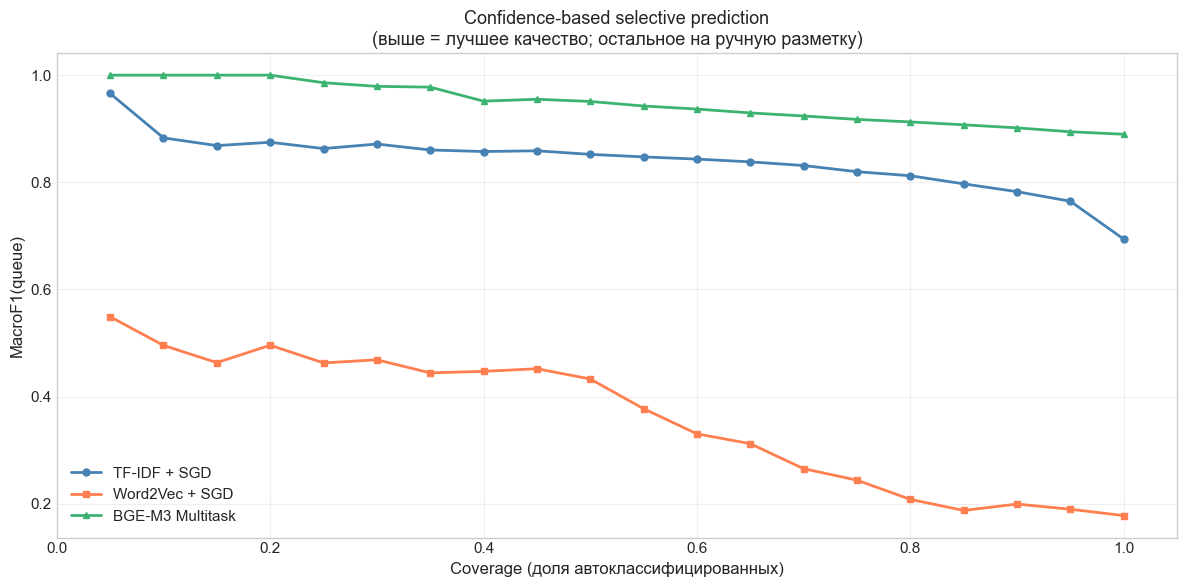


Key coverage points (MacroF1 on queue):
Coverage TF-IDF + SGD Word2Vec + SGD BGE-M3 Multitask
     50%       0.8521         0.4328           0.9509
     70%       0.8313         0.2653           0.9238
     80%       0.8122         0.2081           0.9127
     90%       0.7825         0.1993           0.9016
    100%       0.6940         0.1778           0.8897


In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    "TF-IDF + SGD": "steelblue",
    "Word2Vec + SGD": "coral",
    "BGE-M3 Multitask": "mediumseagreen",
}
markers = {"TF-IDF + SGD": "o", "Word2Vec + SGD": "s", "BGE-M3 Multitask": "^"}

for name, conf_df in all_conf_curves.items():
    ax.plot(
        conf_df["coverage"],
        conf_df["MacroF1(queue)"],
        f"{markers.get(name, 'o')}-",
        label=name,
        color=colors.get(name, "gray"),
        linewidth=2,
        markersize=5,
    )

ax.set_xlabel("Coverage (доля автоклассифицированных)", fontsize=12)
ax.set_ylabel("MacroF1(queue)", fontsize=12)
ax.set_title(
    "Confidence-based selective prediction\n"
    "(выше = лучшее качество; остальное на ручную разметку)",
    fontsize=13,
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

print("\nKey coverage points (MacroF1 on queue):")
key_coverages = [0.5, 0.7, 0.8, 0.9, 1.0]
rows = []
for cov in key_coverages:
    row = {"Coverage": f"{cov:.0%}"}
    for name, conf_df in all_conf_curves.items():
        val = conf_df.loc[conf_df["coverage"] == round(cov, 2), "MacroF1(queue)"]
        row[name] = f"{val.values[0]:.4f}" if len(val) > 0 else "N/A"
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

### Дополнительная диагностика лучшей модели

Ниже смотрим, какие `queue`-классы остаются сложными даже для лучшей модели, и как это связано с размером класса. Отдельно визуализируем confusion matrix по наиболее частым классам, чтобы увидеть типичные направления ошибок.

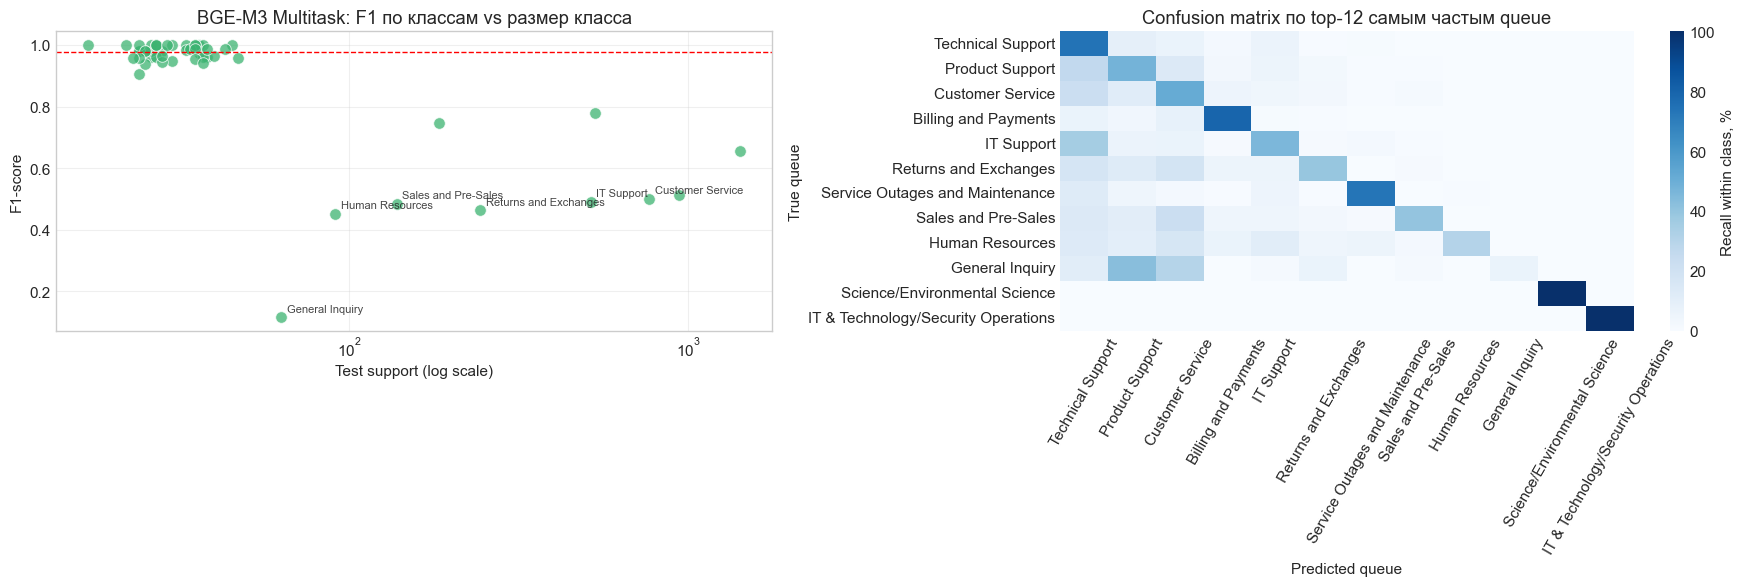

Лучшая модель по MacroF1(queue): BGE-M3 Multitask

Самые сложные классы для queue (по F1):
                                 precision  recall  f1-score  support
General Inquiry                      0.667   0.063     0.116       63
Human Resources                      0.848   0.308     0.452       91
Returns and Exchanges                0.565   0.391     0.462      243
Sales and Pre-Sales                  0.618   0.399     0.485      138
IT Support                           0.524   0.460     0.490      515
Customer Service                     0.488   0.513     0.500      766
Product Support                      0.554   0.479     0.514      937
Technical Support                    0.587   0.742     0.655     1418
Service Outages and Maintenance      0.758   0.734     0.746      184
Billing and Payments                 0.766   0.795     0.780      532


In [25]:
queue_pred_map = {
    "TF-IDF + SGD": tfidf_preds["queue"],
    "Word2Vec + SGD": w2v_preds["queue"],
    "BGE-M3 Multitask": transformer_preds["queue"],
}

best_queue_model = comparison_df["MacroF1(queue)"].idxmax()
best_queue_preds = queue_pred_map[best_queue_model]

y_true_queue = df_test["queue"].astype(str)
report_df = pd.DataFrame(
    classification_report(
        y_true_queue,
        best_queue_preds,
        output_dict=True,
        zero_division=0,
    )
).T
report_df = report_df.loc[
    ~report_df.index.isin(["accuracy", "macro avg", "weighted avg"])
].copy()
report_df["support"] = y_true_queue.value_counts().reindex(report_df.index).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(
    data=report_df,
    x="support",
    y="f1-score",
    ax=axes[0],
    s=70,
    alpha=0.75,
    color="mediumseagreen",
)
axes[0].set_xscale("log")
axes[0].set_title(f"{best_queue_model}: F1 по классам vs размер класса")
axes[0].set_xlabel("Test support (log scale)")
axes[0].set_ylabel("F1-score")
axes[0].axhline(report_df["f1-score"].median(), color="red", ls="--", linewidth=1)
axes[0].grid(True, alpha=0.3)

for label, row in report_df.nsmallest(6, "f1-score").iterrows():
    axes[0].annotate(
        label,
        (row["support"], row["f1-score"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        alpha=0.85,
    )

top_classes = y_true_queue.value_counts().head(12).index.tolist()
cm = confusion_matrix(
    y_true_queue,
    best_queue_preds,
    labels=top_classes,
    normalize="true",
)
cm_df = pd.DataFrame(cm * 100, index=top_classes, columns=top_classes)

sns.heatmap(
    cm_df,
    cmap="Blues",
    ax=axes[1],
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Recall within class, %"},
)
axes[1].set_title("Confusion matrix по top-12 самым частым queue")
axes[1].set_xlabel("Predicted queue")
axes[1].set_ylabel("True queue")
axes[1].tick_params(axis="x", rotation=60)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

print(f"Лучшая модель по MacroF1(queue): {best_queue_model}")
print("\nСамые сложные классы для queue (по F1):")
print(
    report_df.sort_values("f1-score")[
        ["precision", "recall", "f1-score", "support"]
    ].head(10).round(3).to_string()
)

---
## Выводы

- **TF-IDF + SGDClassifier** — быстрый и strong baseline; хорошо работает благодаря n-gram фичам
- **Word2Vec + SGDClassifier** — средние результаты; усреднение word vectors теряет информацию о порядке слов
- **BGE-M3 Multitask** — лучшее качество за счёт контекстных эмбеддингов и совместного обучения на 3 задачи
- **Confidence analysis** показывает, что selective prediction значительно повышает качество: 
  если автоматически классифицировать только наиболее уверенные предсказания, а остальные отправлять на ручную разметку, качество на автоматической части существенно выше